#### Ex.1

In [160]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph

In [161]:
class AgentState(TypedDict):
    name : str

def motivating_node(state: AgentState) -> AgentState:
    state['name'] = state['name'] + ', you\'re doing an amazing job learning LangGraph!'
    return state


In [162]:
graph = StateGraph(AgentState)

graph.add_node("motivate", motivating_node)
graph.set_entry_point("motivate")
graph.set_finish_point("motivate")

app = graph.compile()   

In [163]:
res = app.invoke({'name':'Bob'})
res['name']

"Bob, you're doing an amazing job learning LangGraph!"

### Ex. 2


In [164]:
import math

In [165]:
class AgentState(TypedDict):
    name: str
    values: List[int]
    operations: str
    res : str
def processing(state: AgentState) -> AgentState:
    if (state['operations'] == '*'):
        state['res'] = f'Hi {state['name']}, your answer is: {math.prod(state['values'])}'
    elif(state['operations'] == '+'):
        state['res'] = f'Hi {state['name']}, your answer is: {sum(state['values'])}'
    else:
        print("Not defined this operations")
    return state

In [166]:
graph = StateGraph(AgentState)
graph.add_node("processor", processing)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

In [167]:
final = app.invoke({'name': 'Jack Sparrow', 'values': [1,2,3,4], 'operations': '*', 'res' : ''})
print(final['res'])

Hi Jack Sparrow, your answer is: 24


### Ex. 3

In [168]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    final: str
def first_node(state: AgentState) -> AgentState:
    """ Greeting node """
    state['final'] = f'{state['name']}, welcome to the system!'
    return state
def second_node(state: AgentState) -> AgentState:
    """Describe the user's age"""
    state['final'] += f' You are {state['age']} years old! '
    return state
def third_node(state: AgentState) -> AgentState:
    """Lists the user's skill"""
    formatted_string = ''
    for i in state['skills'][:-1]:
        formatted_string += f'{i}, '
    formatted_string += f'and {state['skills'][-1]}'
    state['final'] += f'You have skills in: {formatted_string}'
    return state 

In [169]:
graph = StateGraph(AgentState)
graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)
graph.set_entry_point('first_node')
graph.set_finish_point('third_node')

graph.add_edge('first_node', 'second_node')
graph.add_edge('second_node', 'third_node')

app = graph.compile()

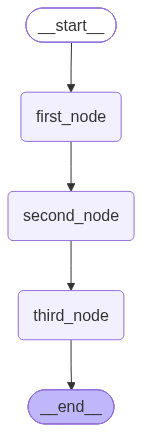

In [170]:
from IPython.display import Image, display

# Vẽ và hiển thị đồ thị của LangGraph
display(Image(app.get_graph().draw_mermaid_png()))

In [171]:
res = app.invoke({'name': 'Son', 'age': 31, 'skills':['Python', 'Machine Learning', 'Go', 'LangGraph'], 'final' : ''})
print(res['final'])

Son, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, Go, and LangGraph


### Ex. 3

In [172]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [173]:
class AgentState(TypedDict):
    number1: int
    operation : str
    number2:  int
    number3: int
    number4: int
    operation2 : str
    finalNumber : int
    finalNumber2: int

In [174]:
def add_node(state: AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] + state['number2']
    return state
def add_node1(state: AgentState) -> AgentState:
    state['finalNumber2'] = state['number3'] + state['number4']
    return state
def subtract_node(state: AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] - state['number2']
    return state
def subtract_node2(state: AgentState) -> AgentState:
    state['finalNumber2'] = state['number3'] - state['number4']
    return state
def router(state:AgentState) -> AgentState:
    if state['operation'] == '+':
        return 'additional_operation'
    elif state['operation'] == '-':
        return 'subtraction_operation'

def router2(state:AgentState) -> AgentState:
    if state['operation2'] == '+':
        return 'additional_operation2'
    elif state['operation2'] == '-':
        return 'subtraction_operation2'

In [175]:
graph = StateGraph(AgentState)

graph.add_node('router', lambda state:state)
graph.add_node('router2', lambda state:state)
graph.add_node('add_node', add_node)
graph.add_node('add_node2', add_node1)
graph.add_node('subtract_node', subtract_node)
graph.add_node('subtract_node2', subtract_node2)

graph.add_conditional_edges(
    'router',
    router,
    {
        'additional_operation' : 'add_node',
        'subtraction_operation' : 'subtract_node'
    }
)
graph.add_conditional_edges(
    'router2',
    router2,
    {
        'additional_operation2': 'add_node2',
        'subtraction_operation2': 'subtract_node2'
    }
)
graph.add_edge(START, 'router')
graph.add_edge('add_node', 'router2')
graph.add_edge('subtract_node', 'router2')
graph.add_edge('add_node2', END)
graph.add_edge('subtract_node2', END)

app = graph.compile()


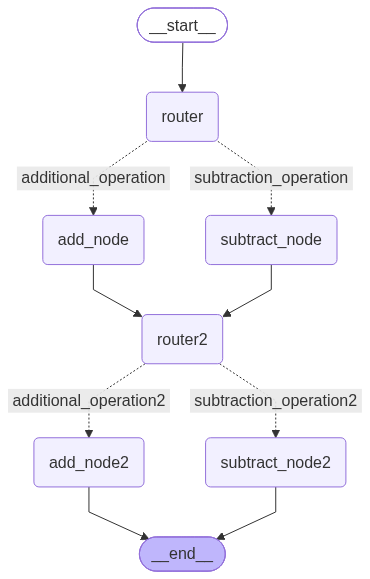

In [176]:
from IPython.display import Image, display

# Vẽ và hiển thị đồ thị của LangGraph
display(Image(app.get_graph().draw_mermaid_png()))

In [177]:
intital_state = app.invoke({'number1' : 10, 'operation': '+', 'number2': 5, 'number3': 7, 'number4' : 2, 'operation2': '-'})
print(intital_state['finalNumber'], intital_state['finalNumber2'] )

15 5


### Ex.4

In [178]:
from typing import TypedDict,List
from langgraph.graph import StateGraph, START, END
import random

In [187]:
class AgentState(TypedDict) :
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    target: int

def setup(state: AgentState) -> AgentState:
    state['target'] = random.randint(state['lower_bound'], state['upper_bound'])
    return state
def guess(state: AgentState) -> AgentState:
    state['guesses'].append(random.randint(state['lower_bound'], state['upper_bound']))
    state['attempts'] += 1     
    return state
def hint_node(state: AgentState) -> dict:
    guess = state['guesses'][-1]
    target = state['target']
    if state['attempts'] < 7 and guess != target:
        if guess < target:
            print("HIGHER")
            return {'lower_bound': guess + 1}
        elif guess > target:
            print("LOWER") 
            return {"upper_bound": guess - 1}
        return {}
def router_node(state: AgentState):
    if state['guesses'][-1] == state['target']:
        print("Done !!!")
        return "finish"
    return "continue"


In [188]:
graph = StateGraph(AgentState)
graph.add_node('setup',setup)
graph.add_node('guess', guess)
graph.add_node('hint_node', hint_node)
graph.add_edge(START, 'setup')
graph.add_edge('setup', 'guess')
graph.add_edge('guess', 'hint_node')
graph.add_conditional_edges(
    'hint_node',
    router_node,
    {
        'continue' : 'guess',
        'finish': END
    }
)
app = graph.compile()

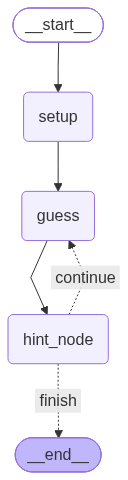

In [185]:
from IPython.display import Image, display

# Vẽ và hiển thị đồ thị của LangGraph
display(Image(app.get_graph().draw_mermaid_png()))

In [189]:
res = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})
print(res)

LOWER
HIGHER
Done !!!
{'player_name': 'Student', 'guesses': [20, 6, 8], 'attempts': 3, 'lower_bound': 7, 'upper_bound': 19, 'target': 8}


### Ex.5. Ez bot

In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [9]:
class AgentState(TypedDict):
    messages : list[str]

def respond(state: AgentState):
    print(f"Tin nhắn cuối: {state['messages'][-1]} \nXin chào, tôi là bot\n")

graph = StateGraph(AgentState)
graph.add_node('respond', respond)
graph.add_edge(START, 'respond')
graph.add_edge('respond', END)

input = {"messages": ['ABC', 'DEF', 'JHI']}
app.invoke(input)

Tin nhắn cuối: JHI 
Xin chào, tôi là bot



{'messages': ['ABC', 'DEF', 'JHI']}

### Ex. 6. Xử lý văn bản 

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage

class AgentState(TypedDict):
    input_text : str
    summarize: str
    translated_text: str

llm = ChatAnthropic(
    model_name='claude-opus-4-7',
    base_url='https://api.agentshop247.com/api/claude',
    temperature=0,
    timeout=None,
    stop=None,
)

def summary(state: AgentState) -> dict:
    full_response = llm.invoke(f"Hãy tóm tắt lại đoạn văn bản {state['input_text']} cho tôi")
    for block in full_response.content:
        if isinstance(block, dict) and block['type'] == 'text':
            response = block['text']
            break
    return {
        'summarize' : response
    }

def translate(state: AgentState) -> dict:
    full_response = llm.invoke(f"Hãy dịch đoạn văn bản sau:\"\"{state['summarize']}\"\" thành tiếng Anh")
    for block in full_response.content:
        if isinstance(block, dict) and block['type'] == 'text':
            response = block['text']
            break
    return {
        'translated_text' : response
    }

graph = StateGraph(AgentState)
graph.add_node('summarized', summary)
graph.add_node('translate', translate)
graph.add_edge(START, 'summarized')
graph.add_edge('summarized', 'translate')
graph.add_edge('translate', END)

app = graph.compile()

res = app.invoke({'input_text':"Bài tập 2: Chuỗi xử lý văn bản (tuần tự) .Mục tiêu: Xây dựng pipeline gồm 3 node xử lý tuần tự: chuẩn hóa → tóm tắt → dịch sang tiếng Anh.Yêu cầu:State chứa input_text, normalized_text, summary, translated_text.Node normalize: loại bỏ dấu, viết thường.Node summarize: rút gọn văn bản (có thể dùng mô hình LLM đơn giản).Node translate: dịch sang tiếng Anh (dùng API hoặc mô hình).Đồ thị có cạnh tuần tự: entry → normalize → summarize → translate → kết thúc.In ra kết quả sau mỗi node.Gợi ý: Sử dụng add_edge để tạo luồng tuyến tính, mỗi node trả về dict cập nhật các trường tương ứng."})

print(res['translated_text'])

## Summary

**Exercise 2: 3-Stage Sequential Text Processing Pipeline**

**Objective:** Build a processing chain consisting of 3 sequential nodes: **Normalize → Summarize → Translate to English**

**State with 4 fields:** `input_text` → `normalized_text` → `summary` → `translated_text`

**Node details:**
| Node | Function | Method |
|------|----------|--------|
| Normalize | Text normalization | Remove punctuation, lowercase |
| Summarize | Content summarization | Use simple LLM |
| Translate | Convert to English | API or translation model |

**Linear processing flow:**
```
entry → normalize → summarize → translate → end
```

**Requirements:** Print results after each node for monitoring. Use `add_edge` to create the flow, each node returns a dict updating the corresponding state.
